## Imports

In [287]:
import pysimdamicm

import ROOT

import pandas as pd
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt

In [288]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.measure import label, regionprops

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

In [289]:
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.default"] = "regular"

### Helpers

Thresholding options

In [290]:
# helper to make threshold cut to image to remove noise
def apply_percentile_threshold(cal_img, percentile=95, fill_value=np.nan):
    """
    Apply a global percentile cut on the RAW calibrated image (E in e-).
    Pixels <= threshold are set to `fill_value` (np.nan by default).

    Returns:
      masked_img : 2D array with only >thr pixels kept
      thr        : numeric threshold used
      keep       : boolean mask (True for kept pixels)
    """
    thr = np.percentile(cal_img, percentile)  # compute on RAW E
    keep = cal_img > thr                      # strict '>' to drop exactly bottom p%
    masked_img = np.where(keep, cal_img, fill_value)
    return masked_img, thr, keep

In [291]:
def apply_energy_threshold(cal_img, thr_keV, fill_value=np.nan):
    """
    Apply a fixed energy threshold to a CCD image calibrated in keV.
    Pixels with energy <= thr_keV are masked out.

    Parameters
    ----------
    cal_img : 2D array (in keV)
        Calibrated CCD image.
    thr_keV : float
        Threshold in keV. Pixels <= thr_keV are suppressed.
    fill_value : number, optional
        Replacement value for masked-out pixels (default: NaN).

    Returns
    -------
    masked_img : 2D array
        Image keeping only pixels above threshold.
    thr_keV : float
        Echo of threshold used.
    keep : 2D boolean array
        True where pixel > thr_keV.
    """
    keep = cal_img > thr_keV
    masked_img = np.where(keep, cal_img, fill_value)
    return masked_img, thr_keV, keep

Make samples logged or not logged in E

In [292]:
# log scale data, may not be necessary but I think I used it for the original so will do it again
def make_samples_logE(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses log(E) as the third feature.
    Assumes masked_img has NaNs or zeros removed already via thresholding.
    
    Returns:
      X_raw : (N,3) with columns [y, x, log(E)]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    # Use pure natural log
    logE = np.log(E)

    X_raw = np.column_stack([ys, xs, logE])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

In [293]:
def make_samples(masked_img):
    """
    Build N x 3 samples from a thresholded CCD image (in keV).
    Uses raw E (no log) as the third feature.

    Returns:
      X_raw : (N,3) with columns [y, x, E]
      idx_yx: (N,2) integer pixel coords [y, x]
    """
    valid = np.isfinite(masked_img) & (masked_img > 0)
    ys, xs = np.nonzero(valid)
    E = masked_img[ys, xs].astype(np.float64)

    X_raw = np.column_stack([ys, xs, E])
    idx_yx = np.column_stack([ys, xs])
    return X_raw, idx_yx

Fit GMM

In [294]:
REG_COVAR = 1e-6
RANDOM_STATE = 209

def _unscale_covariances(gmm, scaler):
    """
    Map covariances from standardized space back to original feature space.
    Handles only covariance_type='full' (what you're using).
    """
    if gmm.covariance_type != "full":
        raise ValueError("This helper currently assumes covariance_type='full'.")

    D = np.diag(scaler.scale_)
    covs_std = gmm.covariances_                 # shape: (K, d, d)
    covs_raw = np.empty_like(covs_std)
    for k in range(covs_std.shape[0]):
        covs_raw[k] = D @ covs_std[k] @ D       # Σ_raw = D Σ_std D
    return covs_raw

def fit_gmms_over_K(X_raw, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE):
    """
    Standardize features, fit a full-covariance GMM for each K.
    Returns: list of dicts with model, labels, BIC, AIC, scaler, and
             means/covariances mapped back to ORIGINAL units.
    """
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_raw)

    results = []
    for K in K_RANGE:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            reg_covar=reg_covar,
            random_state=random_state
        )
        gmm.fit(X_std)

        # Predict labels in standardized space, but keep for reference
        labels = gmm.predict(X_std)

        # --- NEW: parameters in original (unscaled) space ---
        means_raw = scaler.inverse_transform(gmm.means_)       # shape: (K, d)
        covs_raw  = _unscale_covariances(gmm, scaler)          # shape: (K, d, d)

        bic = gmm.bic(X_std)
        aic = gmm.aic(X_std)
        results.append({
            "K": K,
            "model": gmm,
            "labels": labels,         # labels on the standardized X
            "bic": bic,
            "aic": aic,
            "scaler": scaler,
            "means_raw": means_raw,   # <-- in original units
            "covs_raw": covs_raw      # <-- in original units
        })

    results.sort(key=lambda r: r["bic"])
    return results

Plotting options

In [295]:
from matplotlib.colors import ListedColormap

def plot_fullframe_clusters(idx_yx, labels, frame_size=(320, 640), title=None):
    H, W = frame_size
    y = idx_yx[:, 0]
    x = idx_yx[:, 1]

    # ---- Build image storing cluster labels ----
    img = np.full((H, W), -1, dtype=int)
    img[y, x] = labels

    # ---- Define colors ----
    light_blue = [0.45, 0.75, 0.95, 1.0]   # clear light blue
    dark_pink  = [0.80, 0.10, 0.45, 1.0]   # strong pink/magenta

    colors = np.vstack([
        [1, 1, 1, 1],     # background = white
        light_blue,       # cluster 0
        dark_pink         # cluster 1
    ])

    cmap = ListedColormap(colors)

    img_plot = img + 1  # shift background (-1) → 0

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(img_plot, origin='lower', cmap=cmap, interpolation='none')

    ax.set_xlim(0, W)
    ax.set_ylim(0, H)
    ax.set_aspect('equal', 'box')
    ax.set_xlabel("Column index (x)")
    ax.set_ylabel("Row index (y)")
    ax.set_title(title if title else "GMM clusters (full frame)")

    plt.tight_layout()
    plt.show()




In [296]:
def plot_cluster_gallery(idx_yx, result, max_points_per_cluster=None):
    """
    Plot the cluster gallery for a single (best) result.
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]

    K = result["K"]
    labels = result["labels"]

    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.2 * ncols, 3.2 * nrows),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — no overlay", y=0.98)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k // ncols][k % ncols]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        ax.scatter(x_all[sel], y_all[sel], s=2)
        ax.set_aspect("equal", "box")
        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    for kk in range(K, nrows * ncols):
        axes[kk // ncols][kk % ncols].axis("off")

    plt.tight_layout()
    plt.show()


In [297]:
def plot_cluster_gallery_on_frame(idx_yx, result, ccd_shape, max_points_per_cluster=None):
    """
    Plot the cluster gallery for a single (best) result.
    Each panel shows the FULL CCD frame, with only that cluster overplotted.
    
    Parameters
    ----------
    idx_yx : (N, 2) array of [y, x] pixel coordinates
    result : dict with keys "K" and "labels"
    ccd_shape : (H, W) shape of the CCD
    max_points_per_cluster : optional cap on points per cluster
    """
    y_all, x_all = idx_yx[:, 0], idx_yx[:, 1]
    H, W = ccd_shape

    K = result["K"]
    labels = result["labels"]

    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 6 * nrows),
        squeeze=False
    )
    fig.suptitle(f"GMM clusters (K={K}) — full-frame view", y=0.98)

    rng = np.random.default_rng(209)

    for k in range(K):
        ax = axes[k // ncols][k % ncols]
        sel = (labels == k)

        if max_points_per_cluster is not None and sel.sum() > max_points_per_cluster:
            idx = np.flatnonzero(sel)
            idx = rng.choice(idx, size=max_points_per_cluster, replace=False)
            sel = np.zeros_like(labels, dtype=bool)
            sel[idx] = True

        # plot cluster points on full CCD frame
        ax.scatter(x_all[sel], y_all[sel], s=2)

        ax.set_xlim(0, W)
        ax.set_ylim(0, H)
        ax.set_aspect("equal", "box")

        ax.set_title(f"Cluster {k}")
        ax.set_xlabel("x (col)")
        ax.set_ylabel("y (row)")

    for kk in range(K, nrows * ncols):
        axes[kk // ncols][kk % ncols].axis("off")

    plt.tight_layout()
    plt.show()


In [298]:
from matplotlib.colors import ListedColormap

def plot_one_cluster(idx_yx, result, ccd_shape, cluster_id, origin="lower"):
    """
    imshow-style plot (like your example) but only for a single cluster_id.
    """
    H, W = ccd_shape
    labels = np.asarray(result["labels"])

    # pick points for this cluster
    sel = (labels == cluster_id)
    ys = np.asarray(idx_yx[:, 0], dtype=int)[sel]
    xs = np.asarray(idx_yx[:, 1], dtype=int)[sel]

    # make a 0/1 image for this cluster only
    img = np.zeros((H, W), dtype=np.uint8)
    img[ys, xs] = 1

    # colormap: background white, cluster blue (change if you want)
    cmap = ListedColormap(["white", "#1f77b4"])

    plt.figure(figsize=(6, 4))
    plt.imshow(img, origin=origin, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(f"GMM Cluster {cluster_id}")
    plt.xlabel("Column index (x)")
    plt.ylabel("Row index (y)")
    plt.tight_layout()
    plt.show()


### Pull waders calibrated image

In [299]:
fits_path = "/home/dsalma/damicm-ml/img_5_stuff/avg_Image_5_Low_Temp_109_20250807_155031_14_extD_waders.fits"

with fits.open(fits_path) as hdul:
    hdul.info()

Filename: /home/dsalma/damicm-ml/img_5_stuff/avg_Image_5_Low_Temp_109_20250807_155031_14_extD_waders.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  CALIBRATED    1 PrimaryHDU     156   (640, 320)   float64   
  1  PEDSUBTRACTED    1 ImageHDU         8   (640, 320)   float64   
  2  MEAN          1 ImageHDU         8   (640, 320)   float64   


In [300]:
with fits.open(fits_path) as hdul:
    cal_img = hdul[0].data

In [301]:
print("shape:", cal_img.shape)
print("type:", type(cal_img))
print("dtype:", cal_img.dtype)

shape: (320, 640)
type: <class 'numpy.ndarray'>
dtype: >f8


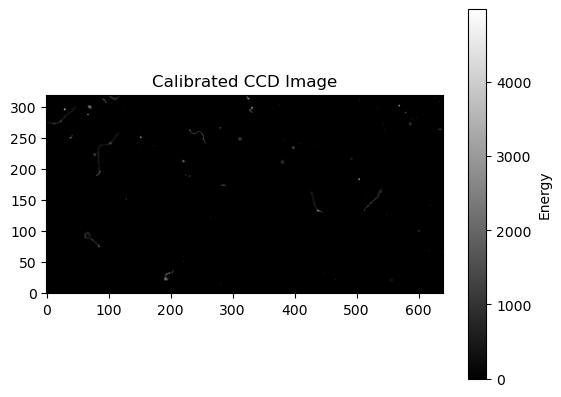

In [302]:
plt.imshow(cal_img, origin="lower", cmap="gray")
plt.colorbar(label="Energy")
plt.title("Calibrated CCD Image")
plt.show()

In [303]:
# convert image from calibration into electron into keV
cal_img = (cal_img * 3.74)/1000  # e- to keV

### GMM analysis

In [304]:
K_RANGE = [2]

In [305]:
# build samples
X_raw_cut, idx_yx = make_samples(cal_img)

In [306]:
results_cut = fit_gmms_over_K(X_raw_cut, K_RANGE, reg_covar=REG_COVAR, random_state=RANDOM_STATE)

In [307]:
best = results_cut[0]

In [308]:
from matplotlib.colors import ListedColormap

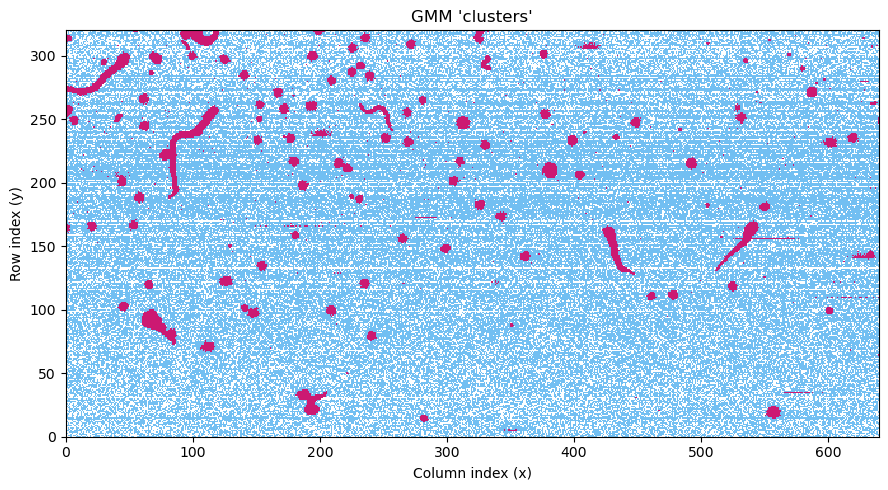

In [354]:
plot_fullframe_clusters(
    idx_yx,
    best["labels"],
    frame_size=cal_img.shape,
    title=f"GMM 'clusters'"
)

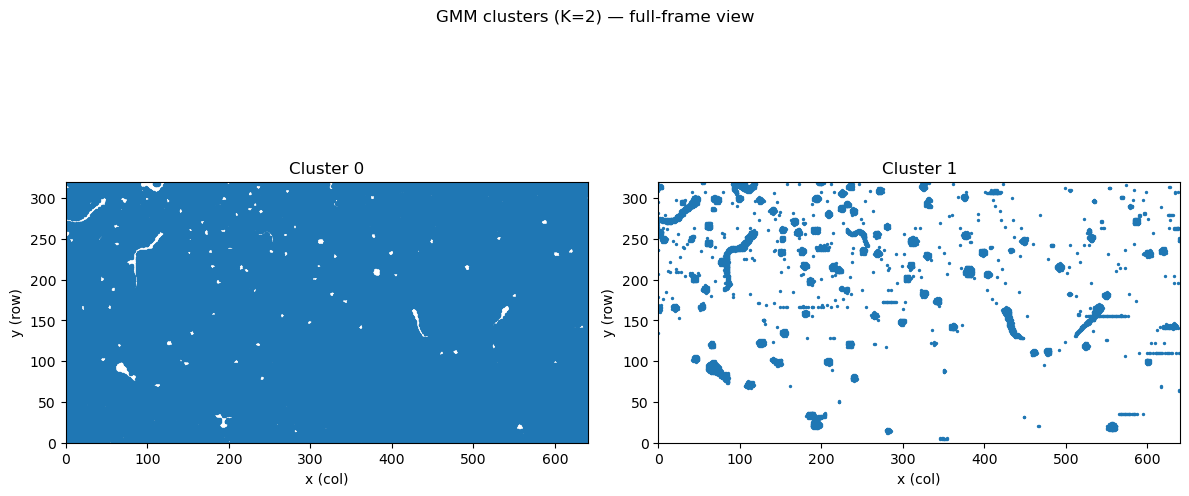

In [310]:
plot_cluster_gallery_on_frame(idx_yx, best, ccd_shape=cal_img.shape)

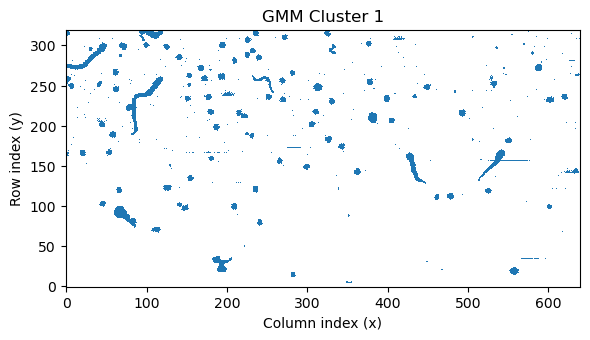

In [355]:
plot_one_cluster(idx_yx, best, ccd_shape=cal_img.shape, cluster_id=1)


In [312]:
import numpy as np
from scipy.ndimage import label as cc_label

def blobs_from_gmm(X_raw, gmm_labels, frame_size, cluster_id):
    """
    X_raw      : (N,3) array [y, x, E]
    gmm_labels : (N,) GMM labels (same order as X_raw)
    frame_size : (H, W)
    cluster_id : GMM component to extract

    Returns:
      blobs   : dict {blob_id: array [[y,x,E], ...]}
      labeled : (H,W) blob-ID image
    """
    H, W = frame_size

    sel = (gmm_labels == cluster_id)
    if not np.any(sel):
        labeled = np.zeros((H, W), dtype=int)
        return {}, labeled

    y = X_raw[sel, 0].astype(int)
    x = X_raw[sel, 1].astype(int)
    E = X_raw[sel, 2].astype(float)

    img = np.zeros((H, W), dtype=np.uint8)
    img[y, x] = 1

    # HARD-CODED 8-connectivity
    labeled = cc_label(img, structure=np.ones((3, 3), dtype=int))[0]

    blob_ids = labeled[y, x]
    blobs = {}

    for bid in np.unique(blob_ids):
        if bid == 0:
            continue
        m = (blob_ids == bid)
        blobs[bid] = np.column_stack([y[m], x[m], E[m]])  # [y,x,E]

    return blobs, labeled


In [313]:
blobs, labeled = blobs_from_gmm(
    X_raw=X_raw_cut,
    gmm_labels=best["labels"],
    frame_size=cal_img.shape,
    cluster_id=1
)

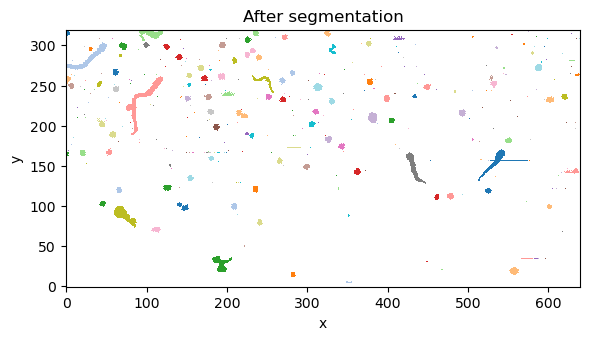

In [314]:
# build a colormap: 0 = white (background), blobs = colors
n_blobs = len(blobs)

colors = [(1, 1, 1, 1)]  # background = white
base = plt.cm.tab20.colors

for i in range(n_blobs):
    colors.append(base[i % len(base)])

cmap = ListedColormap(colors)

plt.figure(figsize=(6, 4))
plt.imshow(labeled, origin="lower", cmap=cmap, interpolation="none")
plt.title("After segmentation")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


In [315]:
# how many blobs
print("Number of blobs:", len(blobs))

# pick a blob ID (e.g. first one)
bid = list(blobs.keys())[0]

blob = blobs[bid]
print(f"Blob {bid} has {len(blob)} pixels")
print("First 10 pixels [y, x, E]:")
print(blob[:10])

Number of blobs: 419
Blob 1 has 2 pixels
First 10 pixels [y, x, E]:
[[5.00000000e+00 3.45000000e+02 3.39032999e-02]
 [6.00000000e+00 3.45000000e+02 1.86839002e-02]]


In [316]:
df_blobs = pd.DataFrame(
    {
        "blob_id": list(blobs.keys()),
        "points": list(blobs.values())
    }
)

In [317]:
df_blobs.head()

,blob_id,points
0,1,"[[5.0, 345.0, 0.03390329986386448], [6.0, 345...."
1,2,"[[5.0, 348.0, 0.02228764518783034], [5.0, 349...."
2,3,"[[12.0, 281.0, 0.033557449956674416], [12.0, 2..."
3,4,"[[15.0, 556.0, 0.026889389504780967], [15.0, 5..."
4,5,"[[18.0, 190.0, 0.029460341386959178], [18.0, 1..."


In [318]:
df_blobs["cluster_size"] = df_blobs["points"].apply(len)

In [319]:
df_blobs.head()

,blob_id,points,cluster_size
0,1,"[[5.0, 345.0, 0.03390329986386448], [6.0, 345....",2
1,2,"[[5.0, 348.0, 0.02228764518783034], [5.0, 349....",10
2,3,"[[12.0, 281.0, 0.033557449956674416], [12.0, 2...",30
3,4,"[[15.0, 556.0, 0.026889389504780967], [15.0, 5...",87
4,5,"[[18.0, 190.0, 0.029460341386959178], [18.0, 1...",232


In [320]:
df_blobs["energy"] = df_blobs["points"].apply(
    lambda pts: np.sum(np.asarray(pts)[:, 2])
)

In [321]:
df_blobs.head()

,blob_id,points,cluster_size,energy
0,1,"[[5.0, 345.0, 0.03390329986386448], [6.0, 345....",2,0.052587
1,2,"[[5.0, 348.0, 0.02228764518783034], [5.0, 349....",10,0.239815
2,3,"[[12.0, 281.0, 0.033557449956674416], [12.0, 2...",30,8.346234
3,4,"[[15.0, 556.0, 0.026889389504780967], [15.0, 5...",87,32.082256
4,5,"[[18.0, 190.0, 0.029460341386959178], [18.0, 1...",232,400.842199


In [322]:

def weighted_std_xy(points):
    """
    points: array of shape (N,3) with columns [y, x, E]
    Returns: wSTD_y, wSTD_x
    """
    y = points[:, 0]
    x = points[:, 1]
    E = points[:, 2]

    Etot = E.sum()
    if Etot == 0:
        return np.nan, np.nan

    y_bar = np.sum(E * y) / Etot
    x_bar = np.sum(E * x) / Etot

    wSTD_y = np.sqrt(np.sum(E * (y - y_bar)**2) / Etot)
    wSTD_x = np.sqrt(np.sum(E * (x - x_bar)**2) / Etot)

    return wSTD_y, wSTD_x

In [323]:
df_blobs[["wSTD_y", "wSTD_x"]] = (
    df_blobs["points"]
    .apply(lambda pts: pd.Series(weighted_std_xy(pts)))
)

In [324]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x
0,1,"[[5.0, 345.0, 0.03390329986386448], [6.0, 345....",2,0.052587,0.478602,5.684342e-14
1,2,"[[5.0, 348.0, 0.02228764518783034], [5.0, 349....",10,0.239815,0.441364,2.186949e+00
2,3,"[[12.0, 281.0, 0.033557449956674416], [12.0, 2...",30,8.346234,1.004304,1.096429e+00
3,4,"[[15.0, 556.0, 0.026889389504780967], [15.0, 5...",87,32.082256,1.533264,1.644187e+00
4,5,"[[18.0, 190.0, 0.029460341386959178], [18.0, 1...",232,400.842199,4.762767,3.879777e+00


In [325]:
df_blobs["wSTD_xy"] = np.sqrt(
    0.5 * (df_blobs["wSTD_x"]**2 + df_blobs["wSTD_y"]**2)
)

In [326]:
df_blobs.head()

,blob_id,points,cluster_size,energy,wSTD_y,wSTD_x,wSTD_xy
0,1,"[[5.0, 345.0, 0.03390329986386448], [6.0, 345....",2,0.052587,0.478602,5.684342e-14,0.338423
1,2,"[[5.0, 348.0, 0.02228764518783034], [5.0, 349....",10,0.239815,0.441364,2.186949e+00,1.577585
2,3,"[[12.0, 281.0, 0.033557449956674416], [12.0, 2...",30,8.346234,1.004304,1.096429e+00,1.051376
3,4,"[[15.0, 556.0, 0.026889389504780967], [15.0, 5...",87,32.082256,1.533264,1.644187e+00,1.589693
4,5,"[[18.0, 190.0, 0.029460341386959178], [18.0, 1...",232,400.842199,4.762767,3.879777e+00,4.343767


lets make these plots!

1. Energy vs. wSTD_xy

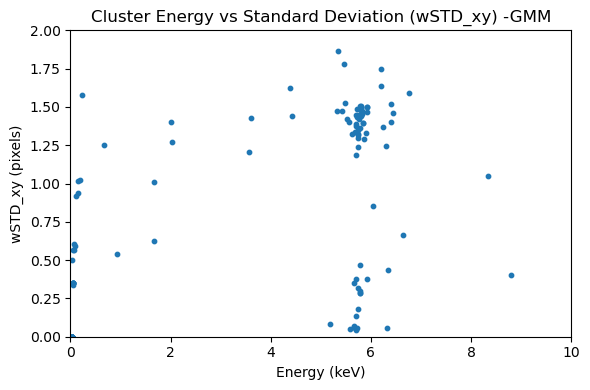

In [327]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["wSTD_xy"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.xlim(0,10)
plt.ylim(0,2)
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) -GMM")
plt.tight_layout()
plt.show()


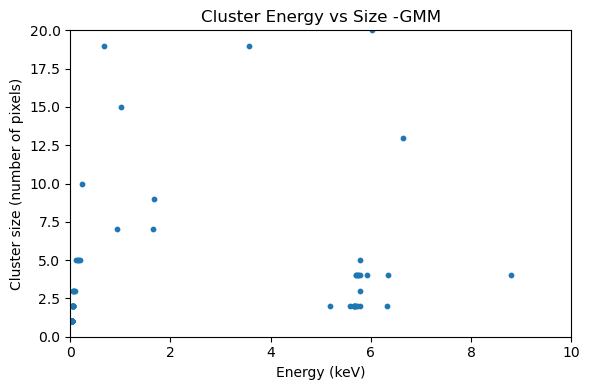

In [328]:
plt.figure(figsize=(6, 4))
plt.scatter(df_blobs["energy"], df_blobs["cluster_size"], s=10)
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size -GMM")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

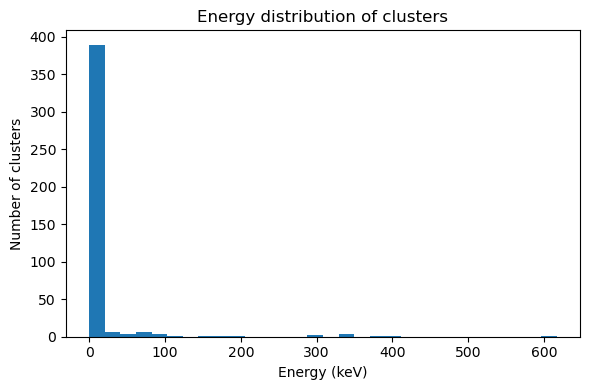

In [329]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=30)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters")
plt.tight_layout()
plt.show()

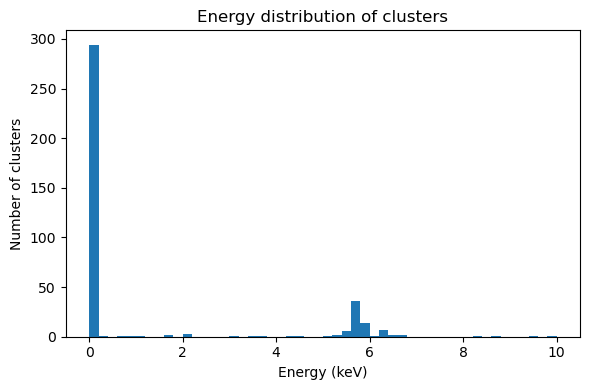

In [330]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(0, 10))
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters")
plt.tight_layout()
plt.show()

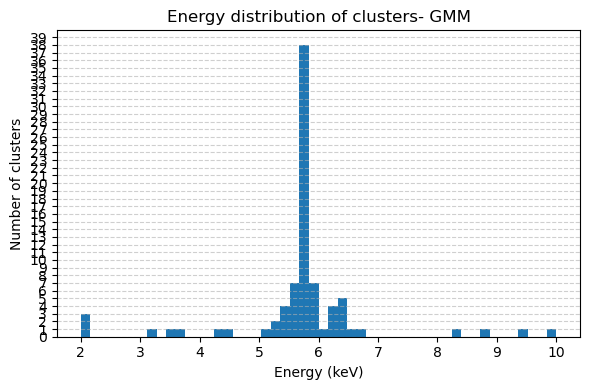

In [331]:
plt.figure(figsize=(6, 4))
plt.hist(df_blobs["energy"], bins=50, range=(2, 10))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- GMM")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

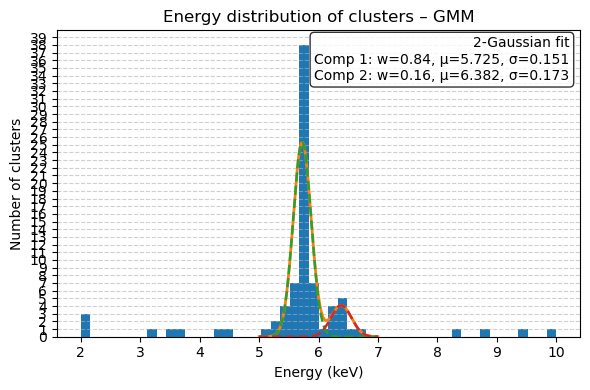

2-Gaussian mixture fit (2–8 keV):
  Comp 1: weight=0.844210, mean=5.725082, std=0.151035
  Comp 2: weight=0.155790, mean=6.381546, std=0.172981


In [332]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# --- histogram settings ---
bins = 50
hist_range = (2, 10)

# --- fit range for the 2-Gaussian mixture ---
fit_min, fit_max = 5.0, 7.0

data = df_blobs["energy"].to_numpy(dtype=float)
data = data[np.isfinite(data)]

# --- data used for fitting ONLY (2–8 keV) ---
fit_data = data[(data >= fit_min) & (data <= fit_max)]

# --- Fit 2-Gaussian mixture to UNBINNED data ---
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
gmm.fit(fit_data.reshape(-1, 1))

means = gmm.means_.ravel()
stds  = np.sqrt(gmm.covariances_.ravel())
weights = gmm.weights_.ravel()

# sort components by mean (for nice reporting/plotting)
order = np.argsort(means)
means, stds, weights = means[order], stds[order], weights[order]

# --- plot histogram (ALL data) ---
plt.figure(figsize=(6, 4))
counts, bin_edges, _ = plt.hist(data, bins=bins, range=hist_range)

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – GMM")

# --- Overlay 2-Gaussian mixture ONLY over 2–8 keV ---
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(fit_min, fit_max, 800)

# total mixture pdf and individual component pdfs
pdf_components = [
    weights[k] * norm.pdf(x, loc=means[k], scale=stds[k])
    for k in range(2)
]
pdf_total = np.sum(pdf_components, axis=0)

# scale PDF(s) to histogram counts
scale = len(fit_data) * bin_width
y_total = pdf_total * scale
y_comps = [pc * scale for pc in pdf_components]

# plot total + components
plt.plot(x, y_total, linewidth=2)
plt.plot(x, y_comps[0], linestyle="--", linewidth=1.8)
plt.plot(x, y_comps[1], linestyle="--", linewidth=1.8)

# --- annotate fit ---
plt.text(
    0.98, 0.98,
    "2-Gaussian fit\n"
    f"Comp 1: w={weights[0]:.2f}, μ={means[0]:.3f}, σ={stds[0]:.3f}\n"
    f"Comp 2: w={weights[1]:.2f}, μ={means[1]:.3f}, σ={stds[1]:.3f}",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- grid ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print("2-Gaussian mixture fit (2–8 keV):")
print(f"  Comp 1: weight={weights[0]:.6f}, mean={means[0]:.6f}, std={stds[0]:.6f}")
print(f"  Comp 2: weight={weights[1]:.6f}, mean={means[1]:.6f}, std={stds[1]:.6f}")


### Waders clusters

In [333]:
import uproot

In [334]:
file = "/home/dsalma/damicm-ml/img_5_stuff/panaSKImg_clustersRec_avg_Image_5_Low_Temp_109_20250807_155031_14_ext3.root"

In [335]:
with uproot.open(file) as f:
    print(f.keys())

['clustersRec;1', 'info;1', 'process_config;1']


In [336]:
clustersRec_tree = f["clustersRec"]

In [337]:
df = clustersRec_tree.arrays(library="pd")

In [338]:
try:
    import awkward as ak
except Exception:
    ak = None

def to_list_maybe(x):
    # Handle common array-likes
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return list(x)
    # Awkward arrays
    if ak is not None:
        try:
            return ak.to_list(x)
        except Exception:
            pass
    # Some awkward objects have .to_list()
    if hasattr(x, "to_list"):
        try:
            return x.to_list()
        except Exception:
            pass
    # Not an array -> return None so we can repeat later
    return None

# --- Choose columns (drop the blockers) ---
cols = [c for c in df.columns if c not in ["RUNID", "Nclusters"]]

# Use the first row (you said there's 1 row)
row = df.iloc[0]

# Find target length (e.g., 991) from the first array-like column
N = None
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is not None:
        N = len(seq)
        break
if N is None:
    raise ValueError("Couldn't find any array-like columns to expand.")

# Build dict of columns -> sequences (repeat scalars)
data = {}
for c in cols:
    seq = to_list_maybe(row[c])
    if seq is None:
        # scalar: repeat it N times
        data[c] = [row[c]] * N
    else:
        data[c] = seq

df_expanded = pd.DataFrame(data).reset_index(drop=True)

print(df_expanded.shape)  
df_expanded.head()

(1845, 56)


,DX,DY,Energy,Energy_AVG,Energy_PS,Npix,PosX,PosY,Qmax,QmaxX,...,readout_end,readout_start,seed_nsig_delta,seed_nsig_max,seed_nsig_min,seed_nsig_pixels,sigma_seed_eV,wSTD_X,wSTD_XY,wSTD_Y
0,1.0,24.0,0.248729,-805.146301,89.116730,24,1.000000,12.381264,0.014037,1.0,...,1.754579e+09,1.754575e+09,1.885522,5.011992,3.126470,"[4.219639778137207, 4.667229652404785, 3.59104...",2.800676,0.000000e+00,4.937286e+00,6.982377e+00
1,2.0,1.0,0.026072,-65.126663,9.341434,2,341.422852,6.000000,0.015048,341.0,...,1.754579e+09,1.754575e+09,1.436543,5.372926,3.936383,"[5.372925758361816, 3.9363832473754883]",2.800676,4.940110e-01,3.493186e-01,8.881784e-16
2,13.0,4.0,0.457061,-767.001282,163.759781,25,350.482819,6.547403,0.033903,346.0,...,1.754579e+09,1.754575e+09,8.876230,12.105398,3.229167,"[3.7970337867736816, 12.105398178100586, 5.363...",2.800676,3.278847e+00,2.377129e+00,7.420563e-01
3,1.0,1.0,0.015037,-31.846281,5.387766,1,358.000000,6.000000,0.015037,358.0,...,1.754579e+09,1.754575e+09,0.000000,5.369238,5.369238,[5.369237899780273],2.800676,5.684342e-14,4.019437e-14,0.000000e+00
4,1.0,1.0,0.015054,-31.830923,5.393652,1,339.000000,7.000000,0.015054,339.0,...,1.754579e+09,1.754575e+09,0.000000,5.375103,5.375103,[5.375102996826172],2.800676,0.000000e+00,0.000000e+00,0.000000e+00


In [339]:
df_expanded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1845 entries, 0 to 1844
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DX                  1845 non-null   float64
 1   DY                  1845 non-null   float64
 2   Energy              1845 non-null   float64
 3   Energy_AVG          1845 non-null   float64
 4   Energy_PS           1845 non-null   float64
 5   Npix                1845 non-null   int64  
 6   PosX                1845 non-null   float64
 7   PosY                1845 non-null   float64
 8   Qmax                1845 non-null   float64
 9   QmaxX               1845 non-null   float64
 10  QmaxY               1845 non-null   float64
 11  RMSX                1845 non-null   float64
 12  RMSY                1845 non-null   float64
 13  STD_X               1845 non-null   float64
 14  STD_XY              1845 non-null   float64
 15  STD_Y               1845 non-null   float64
 16  closes

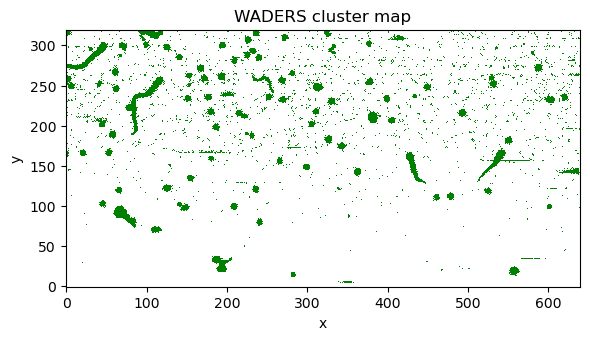

In [356]:
H, W = cal_img.shape
img = np.zeros((H, W), dtype=int)

for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = 1   # mark cluster pixels

# custom colormap: 0 -> white, 1 -> green
from matplotlib.colors import ListedColormap
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(6, 4))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map")
plt.tight_layout()
plt.show()


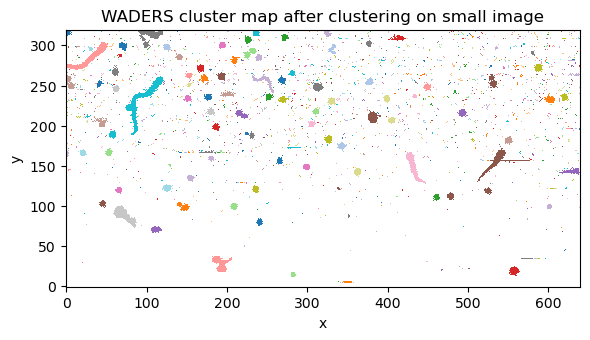

In [341]:
from matplotlib.colors import ListedColormap

H, W = cal_img.shape
img = np.zeros((H, W), dtype=int)

# assign a unique label to each cluster (starting from 1)
for label, (_, row) in enumerate(df_expanded.iterrows(), start=1):
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    img[ys, xs] = label

# build a colormap: 0 = white, clusters = tab20 colors
n_clusters = len(df_expanded)
colors = ["white"] + list(plt.cm.tab20.colors) * ((n_clusters // 20) + 1)
cmap = ListedColormap(colors[: n_clusters + 1])

plt.figure(figsize=(6, 4))
plt.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")
plt.title("WADERS cluster map after clustering on small image")
plt.tight_layout()
plt.show()


In [342]:
len(df_expanded)

1845

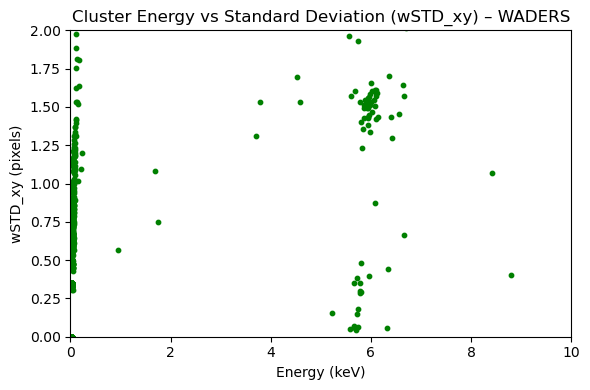

In [343]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["wSTD_XY"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("wSTD_xy (pixels)")
plt.title("Cluster Energy vs Standard Deviation (wSTD_xy) – WADERS")
plt.xlim(0,10)
plt.ylim(0,2)
plt.tight_layout()
plt.show()

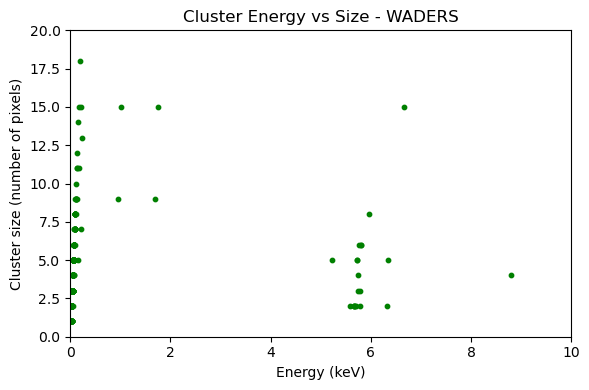

In [344]:
plt.figure(figsize=(6, 4))
plt.scatter(df_expanded["Energy"], df_expanded["Npix"], s=10, c="green")
plt.xlabel("Energy (keV)")
plt.ylabel("Cluster size (number of pixels)")
plt.title("Cluster Energy vs Size - WADERS")
plt.xlim(0,10)
plt.ylim(0,20)
plt.tight_layout()
plt.show()

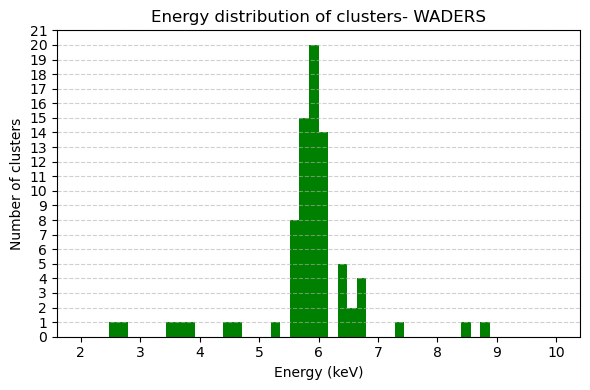

In [345]:
plt.figure(figsize=(6, 4))
plt.hist(df_expanded["Energy"], bins=50, color="green", range=(2, 10))
# range=(0, 10)
plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters- WADERS")

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- light grid aligned with ticks ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

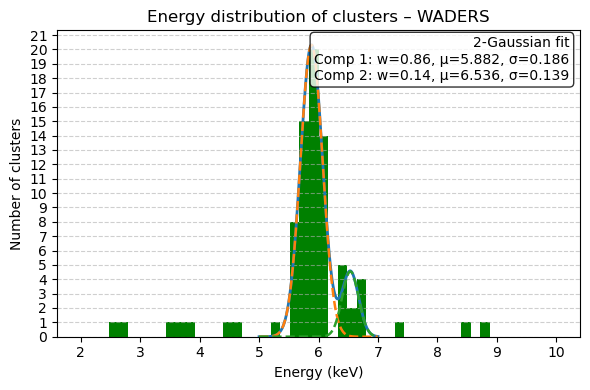

2-Gaussian mixture fit (5–7 keV):
  Comp 1: weight=0.856620, mean=5.882261, std=0.185737
  Comp 2: weight=0.143380, mean=6.535567, std=0.138974


In [346]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# --- settings ---
bins = 50
hist_range = (2, 10)
fit_min, fit_max = 5.0, 7.0   # fit 2 Gaussians only in this window

# --- extract energy ---
data = df_expanded["Energy"].to_numpy(dtype=float)
data = data[np.isfinite(data)]

# --- data used ONLY for mixture fit ---
fit_data = data[(data >= fit_min) & (data <= fit_max)]

# --- Fit 2-Gaussian mixture to UNBINNED data in 5–7 keV ---
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=0)
gmm.fit(fit_data.reshape(-1, 1))

means = gmm.means_.ravel()
stds = np.sqrt(gmm.covariances_.ravel())
weights = gmm.weights_.ravel()

# sort by mean for nicer reporting/plotting
order = np.argsort(means)
means, stds, weights = means[order], stds[order], weights[order]

# --- plot histogram (unchanged from yours) ---
plt.figure(figsize=(6, 4))
counts, bin_edges, _ = plt.hist(
    data, bins=bins, color="green", range=hist_range
)

plt.xlabel("Energy (keV)")
plt.ylabel("Number of clusters")
plt.title("Energy distribution of clusters – WADERS")

# --- overlay 2-Gaussian mixture ONLY over 5–7 keV ---
bin_width = bin_edges[1] - bin_edges[0]
x = np.linspace(fit_min, fit_max, 800)

pdf_components = [
    weights[k] * norm.pdf(x, loc=means[k], scale=stds[k])
    for k in range(2)
]
pdf_total = np.sum(pdf_components, axis=0)

# scale PDFs to histogram counts
scale = len(fit_data) * bin_width
y_total = pdf_total * scale
y_comps = [pc * scale for pc in pdf_components]

# total + each component (dashed)
plt.plot(x, y_total, linewidth=2)
plt.plot(x, y_comps[0], linestyle="--", linewidth=1.8)
plt.plot(x, y_comps[1], linestyle="--", linewidth=1.8)

# --- annotate fit ---
plt.text(
    0.98, 0.98,
    "2-Gaussian fit\n"
    f"Comp 1: w={weights[0]:.2f}, μ={means[0]:.3f}, σ={stds[0]:.3f}\n"
    f"Comp 2: w={weights[1]:.2f}, μ={means[1]:.3f}, σ={stds[1]:.3f}",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# --- integer y-axis ticks ---
ax = plt.gca()
ymax = int(ax.get_ylim()[1])
ax.set_yticks(np.arange(0, ymax + 1, 1))

# --- grid ---
ax.grid(True, axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

print("2-Gaussian mixture fit (5–7 keV):")
print(f"  Comp 1: weight={weights[0]:.6f}, mean={means[0]:.6f}, std={stds[0]:.6f}")
print(f"  Comp 2: weight={weights[1]:.6f}, mean={means[1]:.6f}, std={stds[1]:.6f}")



In [347]:
H, W = cal_img.shape

# --- GMM mask from df_blobs["points"] which stores [y,x,E] arrays ---
gmm_mask = np.zeros((H, W), dtype=bool)
for pts in df_blobs["points"]:
    pts = np.asarray(pts)
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)
    gmm_mask[ys, xs] = True

# --- WADERS mask from df_expanded pixels_x/pixels_y (1-based -> convert to 0-based) ---
waders_mask = np.zeros((H, W), dtype=bool)
for _, row in df_expanded.iterrows():
    xs = np.asarray(row["pixels_x"], dtype=int) - 1
    ys = np.asarray(row["pixels_y"], dtype=int) - 1
    waders_mask[ys, xs] = True

overlap_mask = gmm_mask & waders_mask

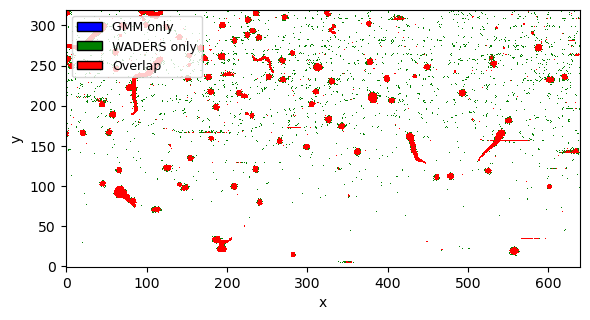

In [348]:
from matplotlib.patches import Patch

overlay = np.zeros((H, W), dtype=int)
overlay[gmm_mask & ~waders_mask] = 1
overlay[waders_mask & ~gmm_mask] = 2
overlay[overlap_mask] = 3

cmap_overlay = ListedColormap(["white", "blue", "green", "red"])

plt.figure(figsize=(6, 4))
plt.imshow(overlay, origin="lower", cmap=cmap_overlay, interpolation="nearest")
plt.xlabel("x")
plt.ylabel("y")

# --- legend ---
legend_elements = [
    Patch(facecolor="blue",  edgecolor="black", label="GMM only"),
    Patch(facecolor="green", edgecolor="black", label="WADERS only"),
    Patch(facecolor="red",   edgecolor="black", label="Overlap"),
]

plt.legend(
    handles=legend_elements,
    loc="upper left",
    frameon=True,
    fontsize=9
)

plt.tight_layout()
plt.show()


Selected bin: [5.800, 6.000) keV | n_blobs=14


/tmp/ipykernel_2007/2594465718.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))


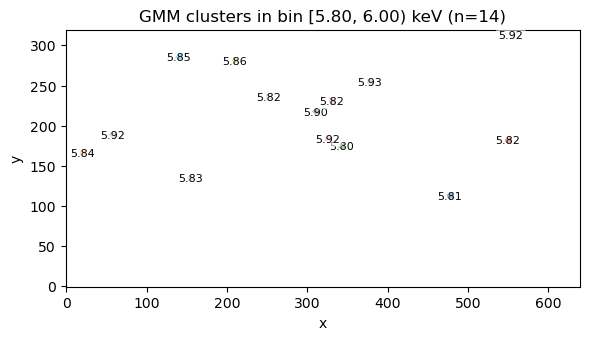

In [349]:
# --- match your histogram ---
BINS = 50
HIST_RANGE = (0, 10)

# 1) SPECIFY BIN (instead of peak bin)
E_lo, E_hi = 5.8, 6.0   # <-- change this whenever you want

df_peak = df_blobs[df_blobs["energy"].between(E_lo, E_hi, inclusive="left")].copy()
print(f"Selected bin: [{E_lo:.3f}, {E_hi:.3f}) keV | n_blobs={len(df_peak)}")

# 2) label map ONLY for those blobs
H, W = cal_img.shape
labels = np.full((H, W), np.nan, dtype=float)

# store centroids for annotation
centroids = []

for j, (_, row) in enumerate(df_peak.iterrows()):
    pts = np.asarray(row["points"], dtype=float)   # [y, x, E]
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)

    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]

    labels[ys, xs] = j

    # centroid in image coordinates
    cx = xs.mean()
    cy = ys.mean()
    centroids.append((cx, cy, row["energy"]))

# 3) plot
cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))
cmap.set_bad("white")

plt.figure(figsize=(6, 4))
plt.imshow(labels, origin="lower", cmap=cmap, interpolation="none")

# annotate energies
for cx, cy, E in centroids:
    plt.text(
        cx, cy, f"{E:.2f}",
        ha="center", va="center",
        fontsize=8,
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
    )

plt.title(f"GMM clusters in bin [{E_lo:.2f}, {E_hi:.2f}) keV (n={len(df_peak)})")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


Selected bin: [5.800, 6.000) keV | n_clusters=23


/tmp/ipykernel_2007/2170251557.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))


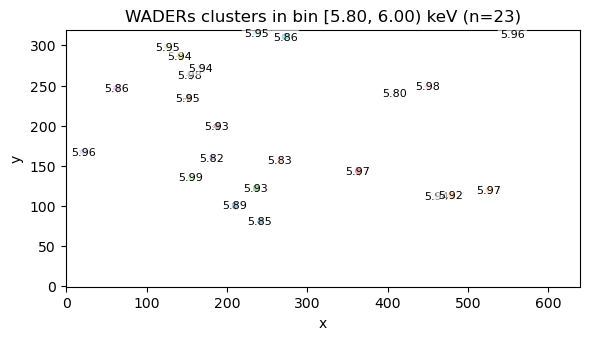

In [350]:
# --- match your histogram settings ---
BINS = 50
HIST_RANGE = (0, 10)

# 1) MANUALLY SPECIFY BIN
E_lo, E_hi = 5.8, 6.0   # <-- change this whenever you want

df_peak = df_expanded[df_expanded["Energy"].between(E_lo, E_hi, inclusive="left")].copy()
print(f"Selected bin: [{E_lo:.3f}, {E_hi:.3f}) keV | n_clusters={len(df_peak)}")

# 2) label map ONLY for those clusters (use cut image dimensions)
H, W = cal_img.shape
labels = np.full((H, W), np.nan, dtype=float)

centroids = []

for j, (_, row) in enumerate(df_peak.iterrows()):
    xs = np.asarray(row["pixels_x"], dtype=int)
    ys = np.asarray(row["pixels_y"], dtype=int)

    # keep in-bounds
    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]
    if xs.size == 0:
        continue

    labels[ys, xs] = j

    # centroid for label
    cx = xs.mean()
    cy = ys.mean()
    centroids.append((cx, cy, float(row["Energy"])))

# 3) plot
cmap = plt.cm.get_cmap("tab20", max(len(df_peak), 1))
cmap.set_bad("white")

plt.figure(figsize=(6, 4))
plt.imshow(labels, origin="lower", cmap=cmap, interpolation="none")

# annotate energies
for cx, cy, E in centroids:
    plt.text(
        cx, cy, f"{E:.2f}",
        ha="center", va="center",
        fontsize=8,
        color="black",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
    )

plt.title(f"WADERs clusters in bin [{E_lo:.2f}, {E_hi:.2f}) keV (n={len(df_peak)})")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()


prev: [5.60,5.80)  peak: [5.80,6.00)  next: [6.00,6.20)
prev  [5.60,5.80) : 36 events
peak  [5.80,6.00) : 14 events
next  [6.00,6.20) : 1 events
TOTAL (3 bins) : 51


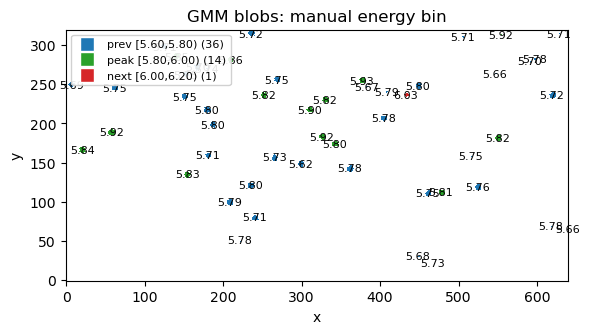

In [351]:
BINS = 50
HIST_RANGE = (0, 10)

# --- MANUALLY SPECIFY ENERGY WINDOW ---
peak_lo, peak_hi = 5.8, 6.0   # <-- change whenever you want

# define neighbor bins using same width
bin_width = peak_hi - peak_lo
prev_lo, prev_hi = peak_lo - bin_width, peak_lo
next_lo, next_hi = peak_hi, peak_hi + bin_width

print(f"prev: [{prev_lo:.2f},{prev_hi:.2f})  "
      f"peak: [{peak_lo:.2f},{peak_hi:.2f})  "
      f"next: [{next_lo:.2f},{next_hi:.2f})")

# --- COUNT EVENTS IN EACH BIN ---
E_all = df_blobs["energy"].to_numpy(float)
E_all = E_all[np.isfinite(E_all)]

n_prev = np.sum((E_all >= prev_lo) & (E_all < prev_hi))
n_peak = np.sum((E_all >= peak_lo) & (E_all < peak_hi))
n_next = np.sum((E_all >= next_lo) & (E_all < next_hi))

print(f"prev  [{prev_lo:.2f},{prev_hi:.2f}) : {n_prev} events")
print(f"peak  [{peak_lo:.2f},{peak_hi:.2f}) : {n_peak} events")
print(f"next  [{next_lo:.2f},{next_hi:.2f}) : {n_next} events")
print(f"TOTAL (3 bins) : {n_prev + n_peak + n_next}")

# --- LABEL IMAGE ---
H, W = cal_img.shape
cls = np.full((H, W), -1, dtype=np.int8)

centroids = []

def class_from_energy(E):
    if prev_lo <= E < prev_hi: return 0
    if peak_lo <= E < peak_hi: return 1
    if next_lo <= E < next_hi: return 2
    return None

for _, row in df_blobs.iterrows():
    E = float(row["energy"])
    c = class_from_energy(E)
    if c is None:
        continue

    pts = np.asarray(row["points"], dtype=float)
    ys = pts[:, 0].astype(int)
    xs = pts[:, 1].astype(int)

    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]
    if xs.size == 0:
        continue

    cls[ys, xs] = c
    centroids.append((xs.mean(), ys.mean(), E))

# --- BUILD RGB IMAGE ---
rgb = np.ones((H, W, 3), dtype=float)

# prev = blue, peak = green, next = red
rgb[cls == 0] = (0.12, 0.47, 0.71)
rgb[cls == 1] = (0.17, 0.63, 0.17)
rgb[cls == 2] = (0.84, 0.15, 0.16)

# --- PLOT ---
plt.figure(figsize=(6, 4))
plt.imshow(rgb, origin="lower", interpolation="none")

for cx, cy, E in centroids:
    plt.text(cx, cy, f"{E:.2f}",
             ha="center", va="center",
             fontsize=8, color="black")

plt.title("GMM blobs: manual energy bin")
plt.xlabel("x")
plt.ylabel("y")

plt.legend(
    handles=[
        plt.Line2D([0],[0], marker="s", color="w",
                   markerfacecolor=(0.12,0.47,0.71), markersize=10,
                   label=f"prev [{prev_lo:.2f},{prev_hi:.2f}) ({n_prev})"),
        plt.Line2D([0],[0], marker="s", color="w",
                   markerfacecolor=(0.17,0.63,0.17), markersize=10,
                   label=f"peak [{peak_lo:.2f},{peak_hi:.2f}) ({n_peak})"),
        plt.Line2D([0],[0], marker="s", color="w",
                   markerfacecolor=(0.84,0.15,0.16), markersize=10,
                   label=f"next [{next_lo:.2f},{next_hi:.2f}) ({n_next})"),
    ],
    loc="upper left",
    fontsize=8,
    framealpha=0.9
)

plt.tight_layout()
plt.show()


prev: [5.60,5.80)  peak: [5.80,6.00)  next: [6.00,6.20)
TOTAL (3 bins) : 53


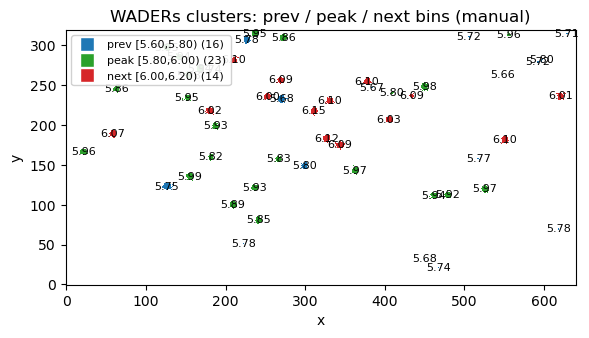

In [352]:
# Must match your histogram
BINS = 50
HIST_RANGE = (0, 10)

# --- MANUALLY SPECIFY BIN (instead of argmax) ---
peak_lo, peak_hi = 5.8, 6.0   # <-- change whenever you want

# define neighbor bins using same width
bin_width = peak_hi - peak_lo
prev_lo, prev_hi = peak_lo - bin_width, peak_lo
next_lo, next_hi = peak_hi, peak_hi + bin_width

print(f"prev: [{prev_lo:.2f},{prev_hi:.2f})  "
      f"peak: [{peak_lo:.2f},{peak_hi:.2f})  "
      f"next: [{next_lo:.2f},{next_hi:.2f})")

# --- label image (store class ids 0,1,2) ---
H, W = cal_img.shape
cls = np.full((H, W), -1, dtype=np.int8)  # -1 = background

centroids = []  # (cx, cy, E)

def class_from_energy(E):
    if prev_lo <= E < prev_hi: return 0
    if peak_lo <= E < peak_hi: return 1
    if next_lo <= E < next_hi: return 2
    return None

# counts that EXACTLY match what's drawn
n_prev = 0
n_peak = 0
n_next = 0

# --- single pass: each cluster decides its own color ---
for _, row in df_expanded.iterrows():
    E = float(row["Energy"])
    c = class_from_energy(E)
    if c is None:
        continue

    xs = np.asarray(row["pixels_x"], dtype=int)
    ys = np.asarray(row["pixels_y"], dtype=int)

    m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
    xs, ys = xs[m], ys[m]
    if xs.size == 0:
        continue

    cls[ys, xs] = c
    centroids.append((xs.mean(), ys.mean(), E))

    # increment counts ONLY for clusters that got drawn
    if c == 0:
        n_prev += 1
    elif c == 1:
        n_peak += 1
    elif c == 2:
        n_next += 1

print(f"TOTAL (3 bins) : {n_prev + n_peak + n_next}")

# --- plot (RGB, no ambiguity) ---
rgb = np.ones((H, W, 3), dtype=float)  # white background

# prev = blue, peak = green, next = red
rgb[cls == 0] = (0.12, 0.47, 0.71)
rgb[cls == 1] = (0.17, 0.63, 0.17)
rgb[cls == 2] = (0.84, 0.15, 0.16)

plt.figure(figsize=(6, 4))
plt.imshow(rgb, origin="lower", interpolation="none")

# optional text (remove if you want)
for cx, cy, E in centroids:
    plt.text(cx, cy, f"{E:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.title("WADERs clusters: prev / peak / next bins (manual)")
plt.xlabel("x"); plt.ylabel("y")

plt.legend(
    handles=[
        plt.Line2D([0],[0], marker="s", color="w",
                   markerfacecolor=(0.12,0.47,0.71), markersize=10,
                   label=f"prev [{prev_lo:.2f},{prev_hi:.2f}) ({n_prev})"),
        plt.Line2D([0],[0], marker="s", color="w",
                   markerfacecolor=(0.17,0.63,0.17), markersize=10,
                   label=f"peak [{peak_lo:.2f},{peak_hi:.2f}) ({n_peak})"),
        plt.Line2D([0],[0], marker="s", color="w",
                   markerfacecolor=(0.84,0.15,0.16), markersize=10,
                   label=f"next [{next_lo:.2f},{next_hi:.2f}) ({n_next})"),
    ],
    loc="upper left",
    fontsize=8,
    framealpha=0.9
)

plt.tight_layout()
plt.show()



WADERs in window: 54
GMM in window:    51
Matched: 50
WADERs-only: 4
GMM-only:    1


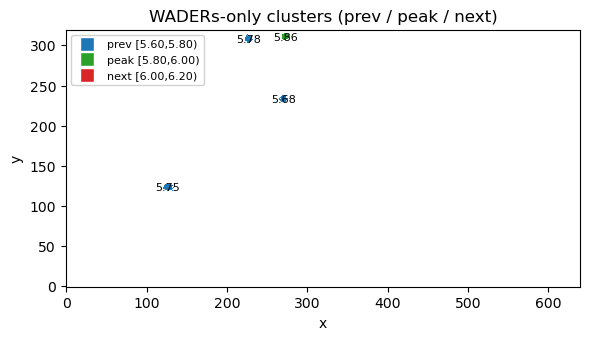

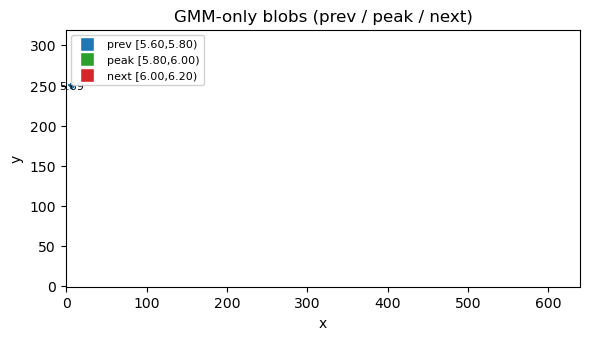

In [353]:
# -------------------------------
# 0) manual bins (same as you use)
# -------------------------------
peak_lo, peak_hi = 5.8, 6.0
bin_width = peak_hi - peak_lo
prev_lo, prev_hi = peak_lo - bin_width, peak_lo
next_lo, next_hi = peak_hi, peak_hi + bin_width
Emin, Emax = prev_lo, next_hi

def class_from_energy(E):
    if prev_lo <= E < prev_hi: return 0
    if peak_lo <= E < peak_hi: return 1
    if next_lo <= E < next_hi: return 2
    return None

# -------------------------------
# 1) extract clusters (pixels + centroid) for both methods
# -------------------------------
def extract_waders(df_expanded):
    out = []
    dfW = df_expanded[df_expanded["Energy"].between(Emin, Emax, inclusive="left")]
    for idx, row in dfW.iterrows():
        E = float(row["Energy"])
        c = class_from_energy(E)
        if c is None:
            continue
        xs = np.asarray(row["pixels_x"], dtype=int)
        ys = np.asarray(row["pixels_y"], dtype=int)
        if xs.size == 0:
            continue
        out.append({
            "id": idx,
            "E": E,
            "c": c,
            "xs": xs,
            "ys": ys,
            "cx": xs.mean(),
            "cy": ys.mean()
        })
    return out

def extract_gmm(df_blobs):
    out = []
    dfG = df_blobs[df_blobs["energy"].between(Emin, Emax, inclusive="left")]
    for idx, row in dfG.iterrows():
        E = float(row["energy"])
        c = class_from_energy(E)
        if c is None:
            continue
        pts = np.asarray(row["points"], dtype=float)  # [y, x, Epix]
        ys = pts[:, 0].astype(int)
        xs = pts[:, 1].astype(int)
        if xs.size == 0:
            continue
        out.append({
            "id": idx,
            "E": E,
            "c": c,
            "xs": xs,
            "ys": ys,
            "cx": xs.mean(),
            "cy": ys.mean()
        })
    return out

W_clusters = extract_waders(df_expanded)
G_clusters = extract_gmm(df_blobs)

print("WADERs in window:", len(W_clusters))
print("GMM in window:   ", len(G_clusters))

# -------------------------------
# 2) 1-to-1 matching by centroid distance
# -------------------------------
tol_px = 6.0      # tune if needed (try 6-10)
dE = None         # set to e.g. 0.05 if you want energy gating

cands = []  # (dist, wi, gi)
for wi, w in enumerate(W_clusters):
    for gi, g in enumerate(G_clusters):
        if dE is not None and abs(w["E"] - g["E"]) > dE:
            continue
        dist = np.hypot(w["cx"] - g["cx"], w["cy"] - g["cy"])
        if dist <= tol_px:
            cands.append((dist, wi, gi))

cands.sort(key=lambda t: t[0])

W_used = set()
G_used = set()
W_to_G = {}  # wi -> gi

for dist, wi, gi in cands:
    if wi in W_used or gi in G_used:
        continue
    W_used.add(wi)
    G_used.add(gi)
    W_to_G[wi] = gi

W_only = [W_clusters[i] for i in range(len(W_clusters)) if i not in W_used]
G_only = [G_clusters[i] for i in range(len(G_clusters)) if i not in G_used]

print("Matched:", len(W_to_G))
print("WADERs-only:", len(W_only))
print("GMM-only:   ", len(G_only))

# -------------------------------
# 3) make "only" label images
# -------------------------------
H, W = cal_img.shape

def make_rgb_from_only(clusters_only, title):
    cls = np.full((H, W), -1, dtype=np.int8)
    centroids = []

    for obj in clusters_only:
        xs = obj["xs"].astype(int)
        ys = obj["ys"].astype(int)

        m = (xs >= 0) & (xs < W) & (ys >= 0) & (ys < H)
        xs, ys = xs[m], ys[m]
        if xs.size == 0:
            continue

        cls[ys, xs] = obj["c"]
        centroids.append((xs.mean(), ys.mean(), obj["E"]))

    rgb = np.ones((H, W, 3), dtype=float)
    rgb[cls == 0] = (0.12, 0.47, 0.71)  # prev
    rgb[cls == 1] = (0.17, 0.63, 0.17)  # peak
    rgb[cls == 2] = (0.84, 0.15, 0.16)  # next

    plt.figure(figsize=(6, 4))
    plt.imshow(rgb, origin="lower", interpolation="none")

    for cx, cy, E in centroids:
        plt.text(cx, cy, f"{E:.2f}", ha="center", va="center", fontsize=8, color="black")

    plt.title(title)
    plt.xlabel("x"); plt.ylabel("y")

    plt.legend(
        handles=[
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.12,0.47,0.71), markersize=10,
                       label=f"prev [{prev_lo:.2f},{prev_hi:.2f})"),
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.17,0.63,0.17), markersize=10,
                       label=f"peak [{peak_lo:.2f},{peak_hi:.2f})"),
            plt.Line2D([0],[0], marker="s", color="w", markerfacecolor=(0.84,0.15,0.16), markersize=10,
                       label=f"next [{next_lo:.2f},{next_hi:.2f})"),
        ],
        loc="upper left",
        fontsize=8,
        framealpha=0.9
    )

    plt.tight_layout()
    plt.show()

# -------------------------------
# 4) plot symmetric difference views
# -------------------------------
make_rgb_from_only(W_only, "WADERs-only clusters (prev / peak / next)")
make_rgb_from_only(G_only, "GMM-only blobs (prev / peak / next)")
